<a href="https://colab.research.google.com/github/mbaker21231/MicroII-Sandbox/blob/main/PureExchangeExample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Worked Pure Exchange Example

We have two utility functions

$$
u_1 = \alpha \sqrt{x} + \sqrt{y}, \quad u_2 = \sqrt{x}+\alpha\sqrt{y}
$$

endowments are $(0,1)$ and $(1,0)$ respectively. Our questions:

1. Sketch an edgeworth box for $\alpha=1$, $\alpha=2$.
2. Describe the core, pareto optima, and equilibria.
3. Find equilibrium prices,
4. If $\alpha=1$, what are the two-replica core points?



To get started with 1:

Equating MRS's from the two utility functions gives:

$$
\frac{\alpha \sqrt{y_1}}{\sqrt{x_1}}=\frac{\sqrt{y_2}}{\alpha\sqrt{x_2}}
$$

Or using resource constraints:

$$
\frac{\alpha \sqrt{y_1}}{\sqrt{x_1}}=\frac{\sqrt{1-y_1}}{\alpha\sqrt{1-x_1}}
$$

So, we can rearrange this as follows:

In [10]:
from sympy import *
import numpy as np

In [4]:
alpha, x, y = symbols('alpha x y', positive=True)

eq = alpha**2*y*(1-x)-(1-y)*x
solns = solve([eq], [y])
solns

{y: -x/(alpha**2*x - alpha**2 - x)}

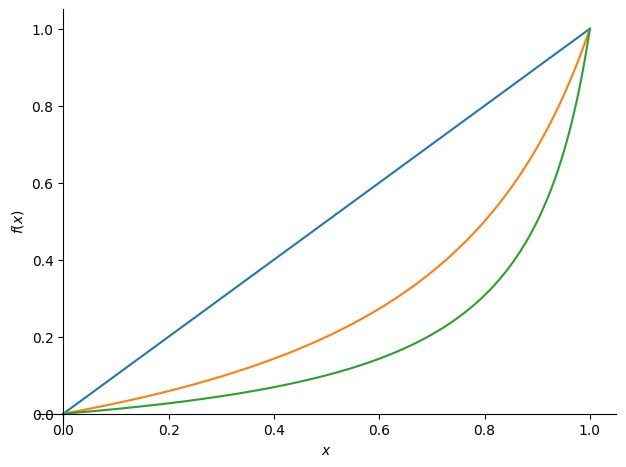

In [7]:
p = plotting.plot(solns[y].subs({alpha:1}),
                  solns[y].subs({alpha:2}),
                  solns[y].subs({alpha:3}), (x, 0, 1))

So we see what happens to the set of pareto optima as we increase $\alpha$.

2. The core restricts our attention to the pareto optima that improve on the lot of both of the two Consumers. At the endowment points, Consumers get utility of $1$. So we think about adding to above indifference curves where:

$$
u_1 = 1 = \alpha \sqrt{x} + \sqrt{y}, \quad u_2 = 1 = \sqrt{x} + \alpha \sqrt{y}
$$

So, we have the first consumer's indifference curve as:

$$
y = \left(1-\alpha\sqrt{x}\right)^2
$$

The second consumer's indifference curve is:

$$
y = \left(\frac{1-\sqrt{x}}{\alpha}\right)^2
$$

But we want to write this in terms of consumer one's perspective, so:

$$
1-y = \left(\frac{1-\sqrt{1-x}}{\alpha}\right)^2
$$

or

$$
y = 1- \left(\frac{1-\sqrt{1-x}}{\alpha}\right)^2
$$


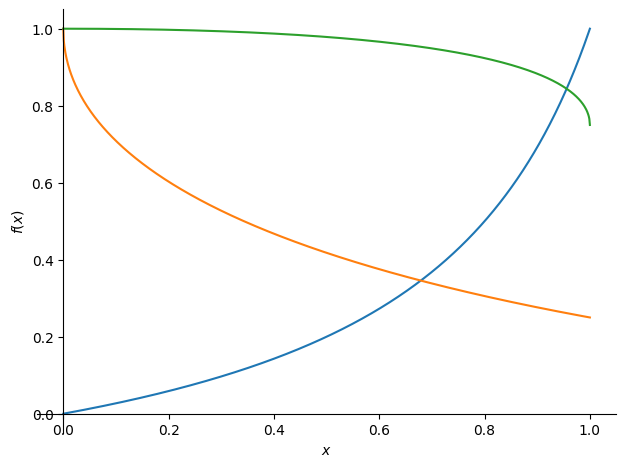

In [8]:
p = plotting.plot(x/(-2**2*x + 2**2 + x),
                  (1-x**(1/2)/2)**2,
                  1-((1-(1-x)**(1/2))/2)**2,
                  (x, 0, 1))

3. Utility is $u=\sqrt{x}+\sqrt{y}$, and budget constraints are defined by $px+y = pe_x+e_y$. We can therefore write: $u = \sqrt{x} + \sqrt{pe_x+e_y-px}$. Maximizing this with respect to $x$ and solving gives demand functions $x^* = \frac{pe_x+e_y}{p(1+p)}$. Substituting in endowments for each of our players, we get:

$$
x_1^* = \frac{1}{1+p}, \quad x_2^* = \frac{1}{p(1+p)}
$$

So aggregate demand is:

$$
\frac{1}{1+p} + \frac{1}{p(1+p)}= \frac{1}{p}
$$

Equating aggregate demand and supply, we get $\frac{1}{p}=1$, and find that $p=1$.

4. We know that, in the 1-replica economy, the point $x_1=\frac{1}{4}, y_1=\frac{1}{4}$ is in the core. This is because utility $\sqrt{x}+\sqrt{y}$ in this case is equal to one, which is the same as would be gotten without exchange.

However, our type one agents, in the 2-replica economy, can do better by peeling a type two agent off and finding the midpoint of the cord between $\frac{1}{4},\frac{1}{4}$, and $(1,0)$, which is the initial endowment. These are consumption points $\frac{5}{8},\frac{1}{8}$. Note at this point, utility is:

In [11]:
np.sqrt(5/8)+np.sqrt(1/8)

np.float64(1.1441228056353687)

Which is slightly more than it is at the endowment. In this case, the two type one consumers get bundles $\frac{5}{8},\frac{1}{8}$, while the type two consumer is given $\frac{3}{4},\frac{3}{4}$ as before (the best possible bundle in the 1-replica economy).

This is feasible because:

$$
\frac{5}{8}2+\frac{3}{4}=2, \quad 2\frac{1}{8}+\frac{3}{4}=1
$$

How does it change our edgeworth box? We need only trace out indifference curves using the new value of utility $1.144122...$

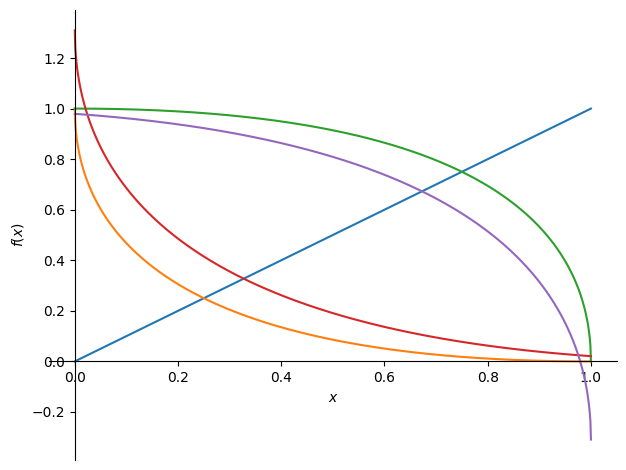

In [12]:
p = plotting.plot(x/(-1**2*x + 1**2 + x),
                  (1-x**(1/2))**2,
                  1-((1-(1-x)**(1/2)))**2,
                  (1.144122-x**(1/2))**2,
                  1-((1.144122-(1-x)**(1/2)))**2,
                  (x, 0, 1))